In [1]:
# 02_ccm_run.ipynb

In [2]:
# Imports and paths

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pyEDM

BASE = Path("../..")   # change if needed
PROCESSED = BASE / "data" / "processed" / "CY-Bench"
RESULTS = BASE / "data" / "results" / "CY-Bench"
RESULTS.mkdir(parents=True, exist_ok=True)

FIGURES = BASE / "figures" / "CY-Bench"
FIGURES.mkdir(parents=True, exist_ok=True)

CROP = "wheat"
COUNTRY = "IN"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [3]:
# Pair files from CCM prep notebook

pair_files = {
    "avg_ssm_avg_ndvi": PROCESSED / "ccm_pair_avg_ssm_avg_ndvi.csv",
    "avg_ssm_avg_fpar": PROCESSED / "ccm_pair_avg_ssm_avg_fpar.csv",
    "avg_ssm_yield": PROCESSED / "ccm_pair_avg_ssm_yield.csv",
    "avg_rsm_avg_ndvi": PROCESSED / "ccm_pair_avg_rsm_avg_ndvi.csv",
    "avg_rsm_avg_fpar": PROCESSED / "ccm_pair_avg_rsm_avg_fpar.csv",
    "avg_rsm_yield": PROCESSED / "ccm_pair_avg_rsm_yield.csv",
    "avg_tavg_avg_cwb": PROCESSED / "ccm_pair_avg_tavg_avg_cwb.csv",
    "avg_prec_yield": PROCESSED / "ccm_pair_avg_prec_yield.csv",
}

pair_files = {k: v for k, v in pair_files.items() if v.exists()}
pair_files

{'avg_ssm_avg_ndvi': PosixPath('../../data/processed/CY-Bench/ccm_pair_avg_ssm_avg_ndvi.csv'),
 'avg_ssm_avg_fpar': PosixPath('../../data/processed/CY-Bench/ccm_pair_avg_ssm_avg_fpar.csv'),
 'avg_ssm_yield': PosixPath('../../data/processed/CY-Bench/ccm_pair_avg_ssm_yield.csv'),
 'avg_rsm_avg_ndvi': PosixPath('../../data/processed/CY-Bench/ccm_pair_avg_rsm_avg_ndvi.csv'),
 'avg_rsm_avg_fpar': PosixPath('../../data/processed/CY-Bench/ccm_pair_avg_rsm_avg_fpar.csv'),
 'avg_rsm_yield': PosixPath('../../data/processed/CY-Bench/ccm_pair_avg_rsm_yield.csv'),
 'avg_tavg_avg_cwb': PosixPath('../../data/processed/CY-Bench/ccm_pair_avg_tavg_avg_cwb.csv'),
 'avg_prec_yield': PosixPath('../../data/processed/CY-Bench/ccm_pair_avg_prec_yield.csv')}

In [4]:
# Load pair tables

pair_data = {name: pd.read_csv(path) for name, path in pair_files.items()}
{name: df.shape for name, df in pair_data.items()}

{'avg_ssm_avg_ndvi': (6460, 16),
 'avg_ssm_avg_fpar': (6460, 16),
 'avg_ssm_yield': (6460, 16),
 'avg_rsm_avg_ndvi': (6460, 16),
 'avg_rsm_avg_fpar': (6460, 16),
 'avg_rsm_yield': (6460, 16),
 'avg_tavg_avg_cwb': (7319, 16),
 'avg_prec_yield': (7319, 16)}

In [5]:
# Sort and basic checks

for name, df in pair_data.items():
    df["adm_id"] = df["adm_id"].astype(str).str.strip()
    df["harvest_year"] = pd.to_numeric(df["harvest_year"], errors="coerce").astype("Int64")
    pair_data[name] = df.sort_values(["adm_id", "harvest_year"]).reset_index(drop=True)

list(pair_data.keys())

['avg_ssm_avg_ndvi',
 'avg_ssm_avg_fpar',
 'avg_ssm_yield',
 'avg_rsm_avg_ndvi',
 'avg_rsm_avg_fpar',
 'avg_rsm_yield',
 'avg_tavg_avg_cwb',
 'avg_prec_yield']

In [6]:
# Helpers to detect the two z-scored signal columns in each pair file

id_like_cols = {
    "crop_name", "country_code", "adm_id", "harvest_year",
    "sos", "eos", "crop_area", "crop_area_percentage",
    "latitude", "longitude", "region_area",
    "awc", "bulk_density", "drainage_class",
    "n_obs"
}

def detect_signal_cols(df):
    z_cols = [c for c in df.columns if c.endswith("_z")]
    if len(z_cols) != 2:
        raise ValueError(f"Expected exactly 2 z-score columns, found {z_cols}")
    return z_cols[0], z_cols[1]

for name, df in pair_data.items():
    print(name, detect_signal_cols(df))

avg_ssm_avg_ndvi ('avg_ssm_z', 'avg_ndvi_z')
avg_ssm_avg_fpar ('avg_ssm_z', 'avg_fpar_z')
avg_ssm_yield ('avg_ssm_z', 'yield_z')
avg_rsm_avg_ndvi ('avg_rsm_z', 'avg_ndvi_z')
avg_rsm_avg_fpar ('avg_rsm_z', 'avg_fpar_z')
avg_rsm_yield ('avg_rsm_z', 'yield_z')
avg_tavg_avg_cwb ('avg_tavg_z', 'avg_cwb_z')
avg_prec_yield ('avg_prec_z', 'yield_z')


In [7]:
# Keep only units with contiguous or near-contiguous yearly coverage
# For the first pass we only require enough rows, not perfect continuity.

MIN_SERIES_LEN = 10

def keep_eligible_units(df, min_len=MIN_SERIES_LEN):
    counts = (
        df.groupby("adm_id", as_index=False)
        .agg(n_obs=("harvest_year", "count"))
    )
    keep_ids = counts.loc[counts["n_obs"] >= min_len, "adm_id"].tolist()
    out = df[df["adm_id"].isin(keep_ids)].copy()
    out = out.sort_values(["adm_id", "harvest_year"]).reset_index(drop=True)
    return out

pair_data = {name: keep_eligible_units(df) for name, df in pair_data.items()}
{name: df.shape for name, df in pair_data.items()}

{'avg_ssm_avg_ndvi': (6460, 16),
 'avg_ssm_avg_fpar': (6460, 16),
 'avg_ssm_yield': (6460, 16),
 'avg_rsm_avg_ndvi': (6460, 16),
 'avg_rsm_avg_fpar': (6460, 16),
 'avg_rsm_yield': (6460, 16),
 'avg_tavg_avg_cwb': (7319, 16),
 'avg_prec_yield': (7319, 16)}

In [8]:
# Build one stitched dataframe per pair with a local time index within each unit.
# We run CCM per adm_id first, then aggregate results across units.

def add_local_time(df):
    df = df.copy()
    df["time"] = df.groupby("adm_id").cumcount() + 1
    return df

pair_data = {name: add_local_time(df) for name, df in pair_data.items()}

In [9]:
# CCM settings

E_VALUES = [2] #same here, you can add more E values
TP = 0
TAU = -1
SAMPLE = 5    # increase this for more stablity and better results
SEED = 42
SHOW_PLOT = False

In [10]:
# Helper to create libSizes string based on available rows

def make_libsizes(n_rows, min_lib=6, step=2):
    max_lib = max(min_lib, n_rows - 2)
    if max_lib <= min_lib:
        return None
    return f"{min_lib} {max_lib} {step}"

In [11]:
# Helper to run CCM for one unit and one ordered pair

def run_ccm_one_unit(df_unit, x_col, y_col, E=2, Tp=0, tau=-1, sample=50, seed=42):
    df_unit = df_unit[["time", x_col, y_col]].dropna().copy()
    df_unit = df_unit.sort_values("time").reset_index(drop=True)

    if len(df_unit) < max(8, E + 3):
        return None

    libs = make_libsizes(len(df_unit), min_lib=max(6, E + 2), step=4)
    if libs is None:
        return None

    try:
        res = pyEDM.CCM(
            dataFrame=df_unit,
            E=E,
            Tp=Tp,
            tau=tau,
            columns=x_col,
            target=y_col,
            libSizes=libs,
            sample=sample,
            seed=seed,
            noTime=False,
            showPlot=False
        )
        return res
    except Exception:
        return None

In [12]:
# Run CCM unit by unit for each pair and each embedding dimension

ccm_runs = []

for pair_name, df_pair in pair_data.items():
    x_col, y_col = detect_signal_cols(df_pair)

    for E in E_VALUES:
        for adm_id, df_unit in df_pair.groupby("adm_id"):
            res = run_ccm_one_unit(
                df_unit=df_unit,
                x_col=x_col,
                
                y_col=y_col,
                E=E,
                Tp=TP,
                tau=TAU,
                sample=SAMPLE,
                seed=SEED
            )

            if res is None or len(res) == 0:
                continue

            res = res.copy()
            res["pair_name"] = pair_name
            res["adm_id"] = adm_id
            res["E"] = E
            res["x_col"] = x_col
            res["y_col"] = y_col
            ccm_runs.append(res)

len(ccm_runs)

3510

In [13]:
# Combine raw CCM outputs

if len(ccm_runs) == 0:
    raise ValueError("No CCM runs returned results. Check pair tables and pyEDM installation.")

ccm_raw = pd.concat(ccm_runs, ignore_index=True)
ccm_raw.head()

,LibSize,avg_ssm_z:avg_ndvi_z,avg_ndvi_z:avg_ssm_z,pair_name,adm_id,E,x_col,y_col,avg_ssm_z:avg_fpar_z,avg_fpar_z:avg_ssm_z,avg_ssm_z:yield_z,yield_z:avg_ssm_z,avg_rsm_z:avg_ndvi_z,avg_ndvi_z:avg_rsm_z,avg_rsm_z:avg_fpar_z,avg_fpar_z:avg_rsm_z,avg_rsm_z:yield_z,yield_z:avg_rsm_z,avg_tavg_z:avg_cwb_z,avg_cwb_z:avg_tavg_z,avg_prec_z:yield_z,yield_z:avg_prec_z
0,6,-0.035881,-0.306262,avg_ssm_avg_ndvi,IN-01-0051,2,avg_ssm_z,avg_ndvi_z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10,-0.083398,-0.363119,avg_ssm_avg_ndvi,IN-01-0051,2,avg_ssm_z,avg_ndvi_z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6,0.012310,-0.312127,avg_ssm_avg_ndvi,IN-01-0052,2,avg_ssm_z,avg_ndvi_z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10,0.031372,-0.327899,avg_ssm_avg_ndvi,IN-01-0052,2,avg_ssm_z,avg_ndvi_z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,-0.060608,-0.238223,avg_ssm_avg_ndvi,IN-01-0053,2,avg_ssm_z,avg_ndvi_z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Inspect CCM output columns

ccm_raw.columns.tolist()

['LibSize',
 'avg_ssm_z:avg_ndvi_z',
 'avg_ndvi_z:avg_ssm_z',
 'pair_name',
 'adm_id',
 'E',
 'x_col',
 'y_col',
 'avg_ssm_z:avg_fpar_z',
 'avg_fpar_z:avg_ssm_z',
 'avg_ssm_z:yield_z',
 'yield_z:avg_ssm_z',
 'avg_rsm_z:avg_ndvi_z',
 'avg_ndvi_z:avg_rsm_z',
 'avg_rsm_z:avg_fpar_z',
 'avg_fpar_z:avg_rsm_z',
 'avg_rsm_z:yield_z',
 'yield_z:avg_rsm_z',
 'avg_tavg_z:avg_cwb_z',
 'avg_cwb_z:avg_tavg_z',
 'avg_prec_z:yield_z',
 'yield_z:avg_prec_z']

In [15]:
# Helper to find columns in pyEDM output

def detect_ccm_output_cols(df):
    lib_col = [c for c in df.columns if c.lower() == "libsize"]
    if len(lib_col) != 1:
        raise ValueError(f"Could not detect LibSize column from {df.columns.tolist()}")
    lib_col = lib_col[0]

    rho_cols = [c for c in df.columns if c != lib_col and ":" in c]
    if len(rho_cols) < 2:
        alt = [c for c in df.columns if c not in [lib_col, "pair_name", "adm_id", "E", "x_col", "y_col"]]
        raise ValueError(f"Could not detect CCM direction columns. Remaining columns: {alt}")
    return lib_col, rho_cols

lib_col, rho_cols = detect_ccm_output_cols(ccm_raw)
lib_col, rho_cols

('LibSize',
 ['avg_ssm_z:avg_ndvi_z',
  'avg_ndvi_z:avg_ssm_z',
  'avg_ssm_z:avg_fpar_z',
  'avg_fpar_z:avg_ssm_z',
  'avg_ssm_z:yield_z',
  'yield_z:avg_ssm_z',
  'avg_rsm_z:avg_ndvi_z',
  'avg_ndvi_z:avg_rsm_z',
  'avg_rsm_z:avg_fpar_z',
  'avg_fpar_z:avg_rsm_z',
  'avg_rsm_z:yield_z',
  'yield_z:avg_rsm_z',
  'avg_tavg_z:avg_cwb_z',
  'avg_cwb_z:avg_tavg_z',
  'avg_prec_z:yield_z',
  'yield_z:avg_prec_z'])

In [16]:
# Reshape raw CCM outputs to long format

meta_cols = ["pair_name", "adm_id", "E", "x_col", "y_col", lib_col]
value_cols = [c for c in rho_cols if c in ccm_raw.columns]

ccm_long = ccm_raw.melt(
    id_vars=meta_cols,
    value_vars=value_cols,
    var_name="direction",
    value_name="rho"
)

ccm_long.head()

,pair_name,adm_id,E,x_col,y_col,LibSize,direction,rho
0,avg_ssm_avg_ndvi,IN-01-0051,2,avg_ssm_z,avg_ndvi_z,6,avg_ssm_z:avg_ndvi_z,-0.035881
1,avg_ssm_avg_ndvi,IN-01-0051,2,avg_ssm_z,avg_ndvi_z,10,avg_ssm_z:avg_ndvi_z,-0.083398
2,avg_ssm_avg_ndvi,IN-01-0052,2,avg_ssm_z,avg_ndvi_z,6,avg_ssm_z:avg_ndvi_z,0.012310
3,avg_ssm_avg_ndvi,IN-01-0052,2,avg_ssm_z,avg_ndvi_z,10,avg_ssm_z:avg_ndvi_z,0.031372
4,avg_ssm_avg_ndvi,IN-01-0053,2,avg_ssm_z,avg_ndvi_z,6,avg_ssm_z:avg_ndvi_z,-0.060608


In [17]:
# Aggregate across units by pair, embedding, and library size

ccm_summary = (
    ccm_long
    .groupby(["pair_name", "E", "direction", lib_col], as_index=False)
    .agg(
        mean_rho=("rho", "mean"),
        median_rho=("rho", "median"),
        std_rho=("rho", "std"),
        n_units=("adm_id", "nunique"),
        n_rows=("rho", "count"),
    )
    .sort_values(["pair_name", "E", "direction", lib_col])
    .reset_index(drop=True)
)

ccm_summary.head(20)

,pair_name,E,direction,LibSize,mean_rho,median_rho,std_rho,n_units,n_rows
0,avg_prec_yield,2,avg_cwb_z:avg_tavg_z,6,NaN,NaN,NaN,441,0
1,avg_prec_yield,2,avg_cwb_z:avg_tavg_z,10,NaN,NaN,NaN,431,0
2,avg_prec_yield,2,avg_cwb_z:avg_tavg_z,14,NaN,NaN,NaN,405,0
3,avg_prec_yield,2,avg_fpar_z:avg_rsm_z,6,NaN,NaN,NaN,441,0
4,avg_prec_yield,2,avg_fpar_z:avg_rsm_z,10,NaN,NaN,NaN,431,0
5,avg_prec_yield,2,avg_fpar_z:avg_rsm_z,14,NaN,NaN,NaN,405,0
6,avg_prec_yield,2,avg_fpar_z:avg_ssm_z,6,NaN,NaN,NaN,441,0
7,avg_prec_yield,2,avg_fpar_z:avg_ssm_z,10,NaN,NaN,NaN,431,0
8,avg_prec_yield,2,avg_fpar_z:avg_ssm_z,14,NaN,NaN,NaN,405,0
9,avg_prec_yield,2,avg_ndvi_z:avg_rsm_z,6,NaN,NaN,NaN,441,0


In [18]:
# Final library-size summary per direction

ccm_final = (
    ccm_summary.sort_values(["pair_name", "E", "direction", lib_col])
    .groupby(["pair_name", "E", "direction"], as_index=False)
    .tail(1)
    .reset_index(drop=True)
    .sort_values(["pair_name", "E", "direction"])
)

ccm_final

,pair_name,E,direction,LibSize,mean_rho,median_rho,std_rho,n_units,n_rows
0,avg_prec_yield,2,avg_cwb_z:avg_tavg_z,14,NaN,NaN,NaN,405,0
1,avg_prec_yield,2,avg_fpar_z:avg_rsm_z,14,NaN,NaN,NaN,405,0
2,avg_prec_yield,2,avg_fpar_z:avg_ssm_z,14,NaN,NaN,NaN,405,0
3,avg_prec_yield,2,avg_ndvi_z:avg_rsm_z,14,NaN,NaN,NaN,405,0
4,avg_prec_yield,2,avg_ndvi_z:avg_ssm_z,14,NaN,NaN,NaN,405,0
...,...,...,...,...,...,...,...,...,...
123,avg_tavg_avg_cwb,2,avg_ssm_z:yield_z,14,NaN,NaN,NaN,405,0
124,avg_tavg_avg_cwb,2,avg_tavg_z:avg_cwb_z,14,0.200471,0.251908,0.3148,405,405
125,avg_tavg_avg_cwb,2,yield_z:avg_prec_z,14,NaN,NaN,NaN,405,0
126,avg_tavg_avg_cwb,2,yield_z:avg_rsm_z,14,NaN,NaN,NaN,405,0


In [19]:
# Choose best E per pair-direction by highest final mean rho

best_ccm = (
    ccm_final.sort_values(["pair_name", "direction", "mean_rho"], ascending=[True, True, False])
    .groupby(["pair_name", "direction"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_ccm

,pair_name,E,direction,LibSize,mean_rho,median_rho,std_rho,n_units,n_rows
0,avg_prec_yield,2,avg_cwb_z:avg_tavg_z,14,NaN,NaN,NaN,405,0
1,avg_prec_yield,2,avg_fpar_z:avg_rsm_z,14,NaN,NaN,NaN,405,0
2,avg_prec_yield,2,avg_fpar_z:avg_ssm_z,14,NaN,NaN,NaN,405,0
3,avg_prec_yield,2,avg_ndvi_z:avg_rsm_z,14,NaN,NaN,NaN,405,0
4,avg_prec_yield,2,avg_ndvi_z:avg_ssm_z,14,NaN,NaN,NaN,405,0
...,...,...,...,...,...,...,...,...,...
123,avg_tavg_avg_cwb,2,avg_ssm_z:yield_z,14,NaN,NaN,NaN,405,0
124,avg_tavg_avg_cwb,2,avg_tavg_z:avg_cwb_z,14,0.200471,0.251908,0.3148,405,405
125,avg_tavg_avg_cwb,2,yield_z:avg_prec_z,14,NaN,NaN,NaN,405,0
126,avg_tavg_avg_cwb,2,yield_z:avg_rsm_z,14,NaN,NaN,NaN,405,0


In [20]:
# Save outputs

ccm_raw_path = RESULTS / "wheat_IN_ccm_raw.csv"
ccm_summary_path = RESULTS / "wheat_IN_ccm_summary.csv"
ccm_final_path = RESULTS / "wheat_IN_ccm_final.csv"
best_ccm_path = RESULTS / "wheat_IN_ccm_best.csv"

ccm_raw.to_csv(ccm_raw_path, index=False)
ccm_summary.to_csv(ccm_summary_path, index=False)
ccm_final.to_csv(ccm_final_path, index=False)
best_ccm.to_csv(best_ccm_path, index=False)

ccm_raw_path, best_ccm_path

(PosixPath('../../data/results/CY-Bench/wheat_IN_ccm_raw.csv'),
 PosixPath('../../data/results/CY-Bench/wheat_IN_ccm_best.csv'))

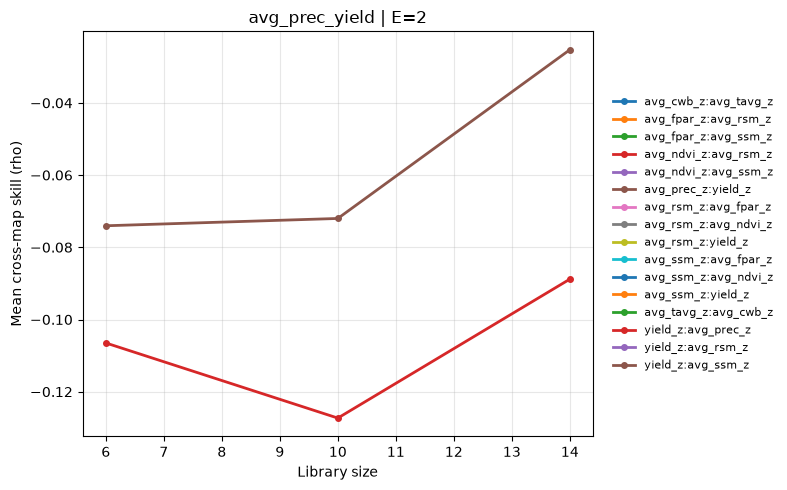

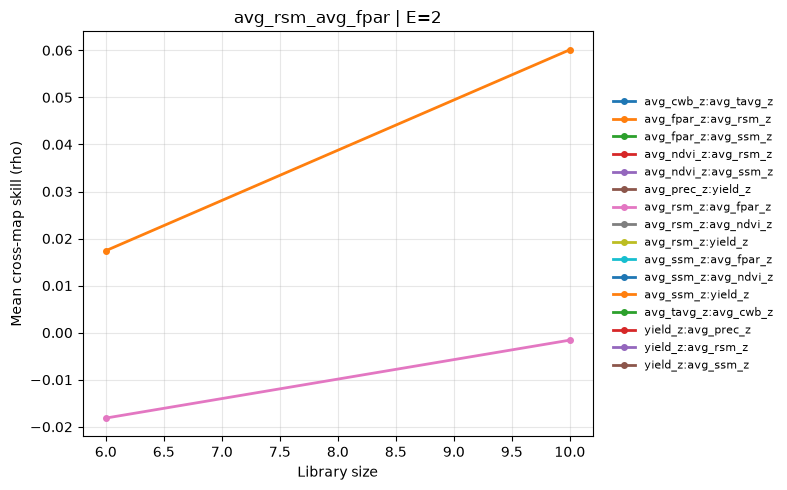

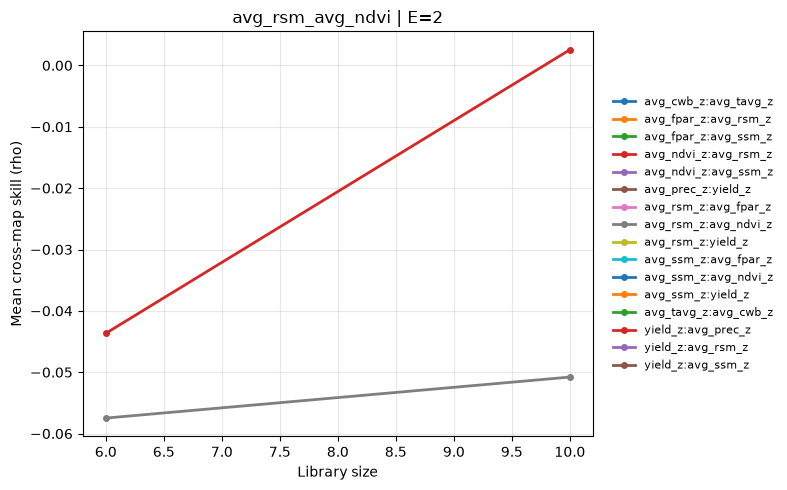

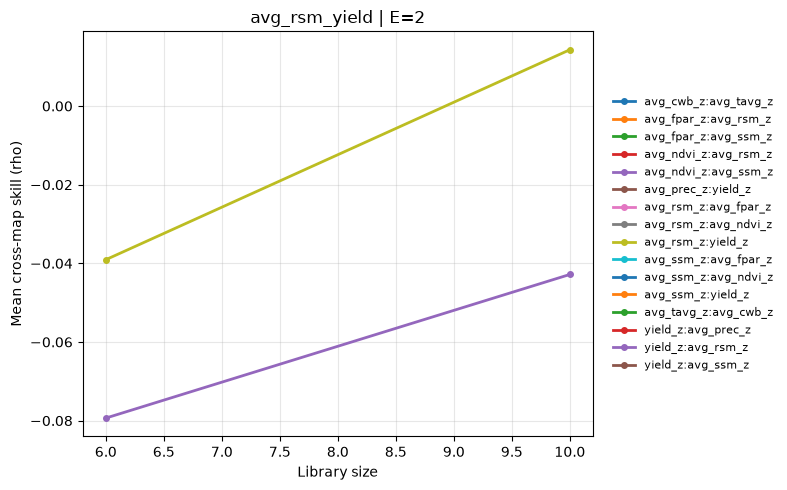

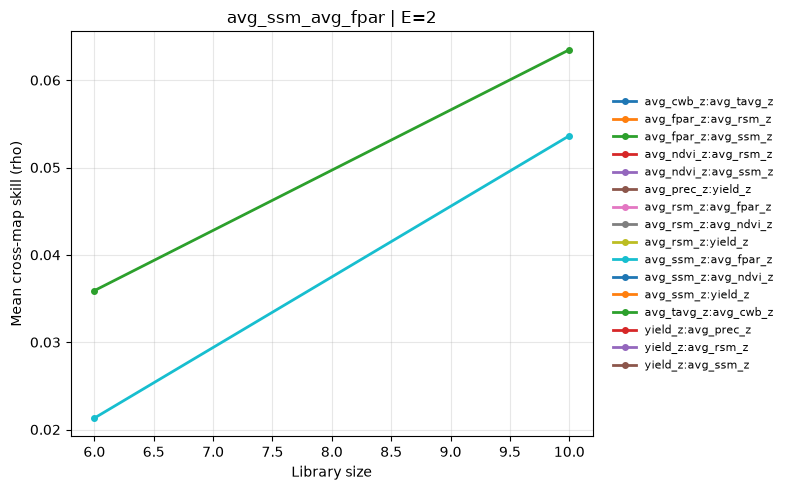

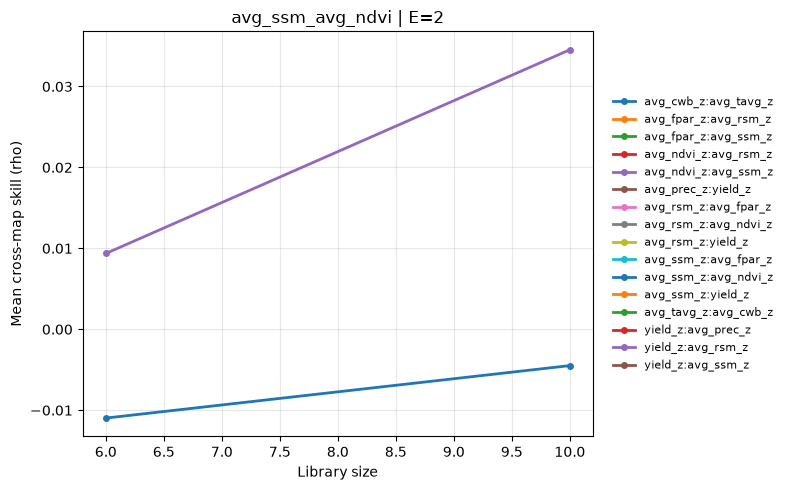

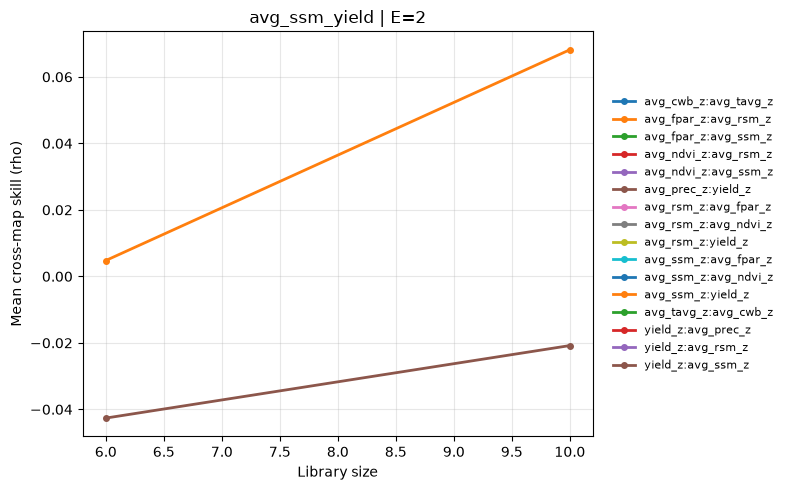

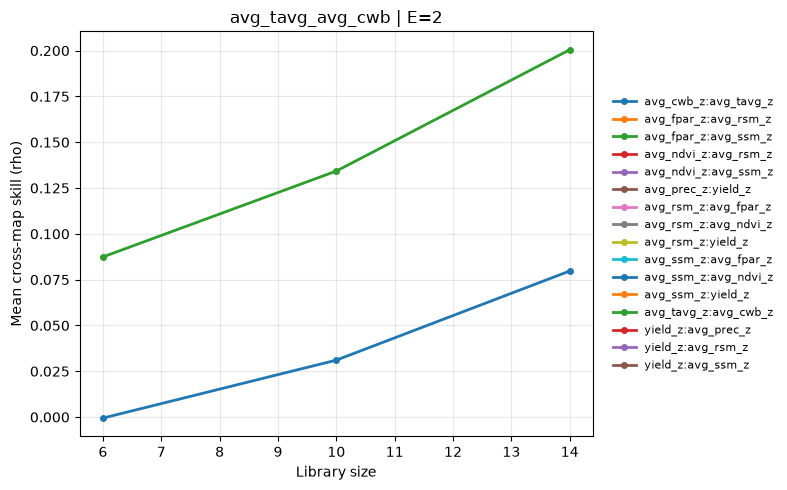

In [25]:
pairs = sorted(ccm_summary["pair_name"].unique())

for pair_name in pairs:
    for E in sorted(ccm_summary.loc[ccm_summary["pair_name"] == pair_name, "E"].unique()):
        dfp = ccm_summary[
            (ccm_summary["pair_name"] == pair_name) &
            (ccm_summary["E"] == E)
        ].copy()

        fig, ax = plt.subplots(figsize=(8, 5))

        for direction, dfd in dfp.groupby("direction"):
            dfd = dfd.sort_values(lib_col)
            ax.plot(
                dfd[lib_col],
                dfd["mean_rho"],
                marker="o",
                linewidth=2,
                markersize=4,
                label=direction
            )

        ax.set_title(f"{pair_name} | E={E}")
        ax.set_xlabel("Library size")
        ax.set_ylabel("Mean cross-map skill (rho)")
        ax.grid(alpha=0.3)
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            fontsize=8
        )

        fig.tight_layout()

        png_path = FIGURES / f"plot_{pair_name}_E{E}.png"
        fig.savefig(png_path, bbox_inches="tight", dpi=300)
        plt.show()
        plt.close(fig)

In [22]:
# Compact interpretation table

interpretation = (
    best_ccm[["pair_name", "E", "direction", "mean_rho", "median_rho", "n_units"]]
    .sort_values(["pair_name", "mean_rho"], ascending=[True, False])
    .reset_index(drop=True)
)

interpretation

,pair_name,E,direction,mean_rho,median_rho,n_units
0,avg_prec_yield,2,avg_prec_z:yield_z,-0.025280,-0.036263,405
1,avg_prec_yield,2,yield_z:avg_prec_z,-0.088819,-0.117278,405
2,avg_prec_yield,2,avg_cwb_z:avg_tavg_z,NaN,NaN,405
3,avg_prec_yield,2,avg_fpar_z:avg_rsm_z,NaN,NaN,405
4,avg_prec_yield,2,avg_fpar_z:avg_ssm_z,NaN,NaN,405
...,...,...,...,...,...,...
123,avg_tavg_avg_cwb,2,avg_ssm_z:avg_ndvi_z,NaN,NaN,405
124,avg_tavg_avg_cwb,2,avg_ssm_z:yield_z,NaN,NaN,405
125,avg_tavg_avg_cwb,2,yield_z:avg_prec_z,NaN,NaN,405
126,avg_tavg_avg_cwb,2,yield_z:avg_rsm_z,NaN,NaN,405


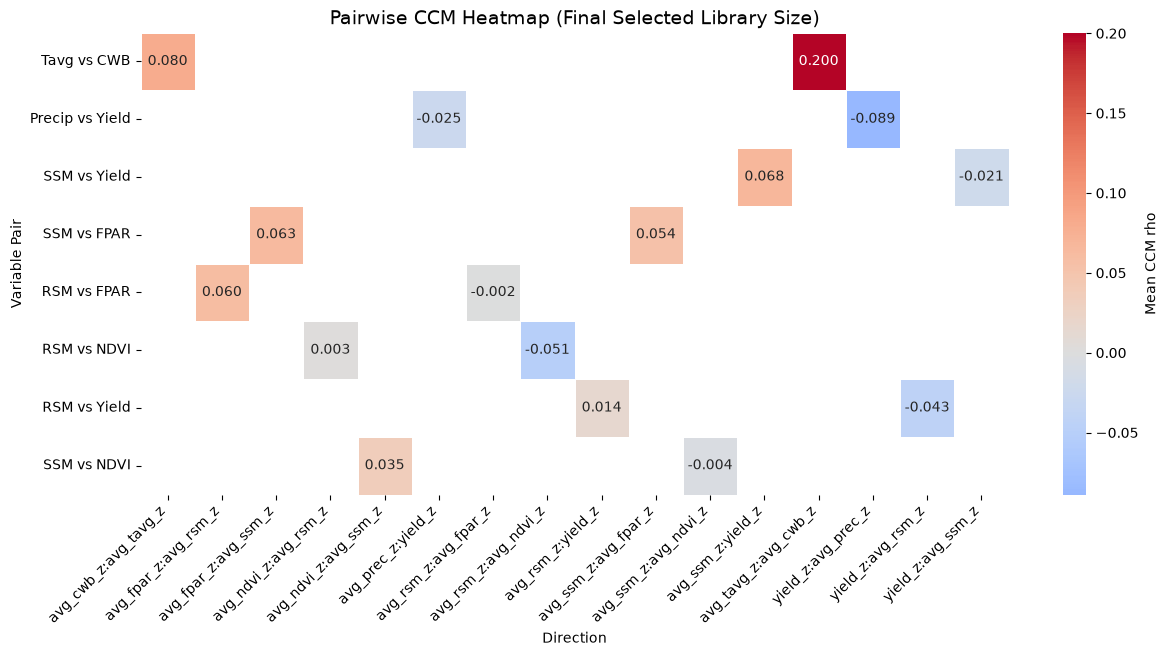

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load final CCM summary
ccm_final = pd.read_csv("../../data/results/CY-Bench-02/wheat_IN_ccm_final.csv")

# Keep only rows with an actual CCM score
df = ccm_final.copy()
df["mean_rho"] = pd.to_numeric(df["mean_rho"], errors="coerce")
df = df.dropna(subset=["mean_rho"])

# Optional: cleaner labels for plot
pair_label_map = {
    "avg_ssm_yield": "SSM vs Yield",
    "avg_rsm_yield": "RSM vs Yield",
    "avg_ssm_avg_ndvi": "SSM vs NDVI",
    "avg_rsm_avg_ndvi": "RSM vs NDVI",
    "avg_ssm_avg_fpar": "SSM vs FPAR",
    "avg_rsm_avg_fpar": "RSM vs FPAR",
    "avg_prec_yield": "Precip vs Yield",
    "avg_tavg_avg_cwb": "Tavg vs CWB",
}
df["pair_label"] = df["pair_name"].map(pair_label_map).fillna(df["pair_name"])

# Pivot for heatmap
heatmap_df = df.pivot_table(
    index="pair_label",
    columns="direction",
    values="mean_rho",
    aggfunc="first"
)

# Order rows by strongest absolute signal
row_order = heatmap_df.abs().max(axis=1).sort_values(ascending=False).index
heatmap_df = heatmap_df.loc[row_order]

# Plot
plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean CCM rho"}
)

plt.title("Pairwise CCM Heatmap (Final Selected Library Size)", fontsize=14)
plt.xlabel("Direction")
plt.ylabel("Variable Pair")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig("../../figures/CY-Bench-02/pairwise-heatmap", bbox_inches='tight', dpi = 300)